In [4]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
from torchsummary import summary


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
img_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

trn_ds = MNIST('./data', transform=img_transforms, train=True, download=True)
val_ds = MNIST('./data', transform=img_transforms, train=True, download=True)

batch_size = 128
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [35]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,stride=3,padding=1), nn.ReLU(True),
            nn.MaxPool2d(2,stride=2),
            nn.Conv2d(32,64,3,stride=3,padding=1), nn.ReLU(True),
            nn.MaxPool2d(2,stride=1)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 2, stride=1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=3, padding=1, output_padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(32, 32, 2, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 3, stride=3, padding=1), nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = ConvAutoEncoder()
summary(model, (1, 28, 28))# uas imagens por vez, com tom cinza(1 canal), e imagem 28x28

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 10, 10]             320
              ReLU-2           [-1, 32, 10, 10]               0
         MaxPool2d-3             [-1, 32, 5, 5]               0
            Conv2d-4             [-1, 64, 2, 2]          18,496
              ReLU-5             [-1, 64, 2, 2]               0
         MaxPool2d-6             [-1, 64, 1, 1]               0
   ConvTranspose2d-7             [-1, 64, 2, 2]          16,448
              ReLU-8             [-1, 64, 2, 2]               0
   ConvTranspose2d-9             [-1, 32, 5, 5]          18,464
             ReLU-10             [-1, 32, 5, 5]               0
  ConvTranspose2d-11           [-1, 32, 10, 10]           4,128
             ReLU-12           [-1, 32, 10, 10]               0
  ConvTranspose2d-13            [-1, 1, 28, 28]             289
             Tanh-14            [-1, 1,

In [36]:
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

In [37]:
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

In [38]:
model = ConvAutoEncoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.0001)

In [39]:
epochs=5
log=Report(epochs)

for epoch in range(epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)


EPOCH: 1.000  trn_loss: 0.241  val_loss: 0.150  (30.56s - 122.23s remaining)
EPOCH: 2.000  trn_loss: 0.121  val_loss: 0.103  (53.08s - 79.61s remaining)
EPOCH: 3.000  trn_loss: 0.094  val_loss: 0.088  (67.04s - 44.69s remaining)
EPOCH: 4.000  trn_loss: 0.083  val_loss: 0.079  (107.83s - 26.96s remaining)
EPOCH: 5.000  trn_loss: 0.077  val_loss: 0.074  (141.39s - 0.00s remaining)


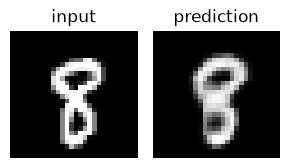

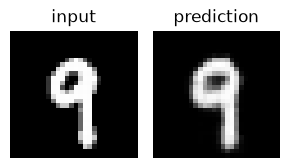

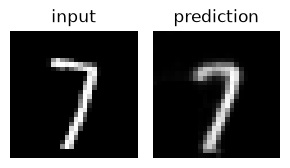

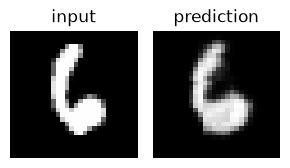

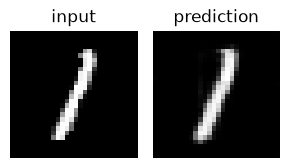

In [ ]:
for _ in range(5):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig,ax =plt.subplots(1,2,figsize =(3,3))
    show(im[0],ax=ax[0], title='input')
    show(_im[0],ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

In [41]:
latent_vectors = []
classes = []
for im,clss in val_dl:
    latent_vectors.append(model.encoder(im))
    classes.extend(clss)
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy().reshape(10000, -1)


In [ ]:
rand_vectors = []#ger novos vetores baseado na distribuição 
for col in latent_vectors.transpose(1,0):
    mu, sigma = col.mean(), col.std()
    rand_vectors.append(sigma*torch.randn(1,100) + mu)